In [1]:
# 1/6 — A100, lisanslı ek veri ve dosya yapısı denetimi
from pathlib import Path
import json, os, shutil, subprocess, sys, zipfile
import torch

print("CUDA", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU", torch.cuda.get_device_name(0), "VRAM_GB", round(torch.cuda.get_device_properties(0).total_memory/2**30, 1))

ASL_HG_ZIP = Path("/content/ASL_HG_36000_CC_BY_4.zip")
if not ASL_HG_ZIP.exists():
    subprocess.run([
        "wget", "-q", "--show-progress",
        "https://data.mendeley.com/public-api/zip/j4y5w2c8w9/download/1",
        "-O", str(ASL_HG_ZIP)
    ], check=True)

with zipfile.ZipFile(ASL_HG_ZIP) as zf:
    names = zf.namelist()
    bad = zf.testzip()
# 1/6 — A100, lisanslı ek veri ve dosya yapısı denetimi
from pathlib import Path
import json, os, shutil, subprocess, sys, zipfile
import torch

print("CUDA", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU", torch.cuda.get_device_name(0), "VRAM_GB", round(torch.cuda.get_device_properties(0).total_memory/2**30, 1))

ASL_HG_ZIP = Path("/content/ASL_HG_36000_CC_BY_4.zip")
if not ASL_HG_ZIP.exists():
    subprocess.run([
        "wget", "-q", "--show-progress",
        "https://data.mendeley.com/public-api/zip/j4y5w2c8w9/download/1",
        "-O", str(ASL_HG_ZIP)
    ], check=True)

with zipfile.ZipFile(ASL_HG_ZIP) as zf:
    names = zf.namelist()
    bad = zf.testzip()
print("ASL_HG_ZIP_GB", round(ASL_HG_ZIP.stat().st_size/2**30, 3))
print("ZIP_ENTRIES", len(names), "CRC_ERROR", bad)
print(*names[:160], sep=chr(10))


CUDA True
GPU NVIDIA A100-SXM4-40GB VRAM_GB 39.5
CUDA True
GPU NVIDIA A100-SXM4-40GB VRAM_GB 39.5
ASL_HG_ZIP_GB 1.128
ZIP_ENTRIES 2 CRC_ERROR None
ASL-HG American Sign Language Hand Gesture Image D/ASL_HG_36000/ASL_Processed_Images.zip
ASL-HG American Sign Language Hand Gesture Image D/ASL_HG_36000/ASL_Raw_Images.zip


In [2]:
# 2/6 — İç arşiv, sınıf ve katılımcı adlandırma denetimi
from collections import Counter
NESTED_ROOT = Path("/content/asl_hg_nested")
NESTED_ROOT.mkdir(exist_ok=True)
with zipfile.ZipFile(ASL_HG_ZIP) as outer:
    outer.extractall(NESTED_ROOT)

for nested_zip in sorted(NESTED_ROOT.rglob("*.zip")):
    with zipfile.ZipFile(nested_zip) as inner:
        inner_names = [name for name in inner.namelist() if not name.endswith("/")]
        print("INNER", nested_zip.name, "FILES", len(inner_names), "GB", round(nested_zip.stat().st_size/2**30, 3))
        print("CRC", inner.testzip())
        print(*inner_names[:120], sep=chr(10))
        print("PATH_DEPTHS", Counter(len(Path(name).parts) for name in inner_names))
        print("SUFFIXES", Counter(Path(name).suffix.lower() for name in inner_names))
        print("BASENAME_SAMPLES", [Path(name).name for name in inner_names[:40]])


INNER ASL_Processed_Images.zip FILES 36000 GB 0.357
CRC None
asl_processed/test/N/P4_N_397.jpg
asl_processed/test/N/P2_N_154.jpg
asl_processed/test/N/P6_N_583.jpg
asl_processed/test/N/P9_N_813.jpg
asl_processed/test/N/P5_N_479.jpg
asl_processed/test/N/P1_N_3.jpg
asl_processed/test/N/P1_N_72.jpg
asl_processed/test/N/P9_N_885.jpg
asl_processed/test/N/P3_N_202.jpg
asl_processed/test/N/P9_N_898.jpg
asl_processed/test/N/P5_N_472.jpg
asl_processed/test/N/P3_N_272.jpg
asl_processed/test/N/P7_N_632.jpg
asl_processed/test/N/P7_N_674.jpg
asl_processed/test/N/P3_N_261.jpg
asl_processed/test/N/P1_N_68.jpg
asl_processed/test/N/P5_N_417.jpg
asl_processed/test/N/P5_N_450.jpg
asl_processed/test/N/P6_N_585.jpg
asl_processed/test/N/P3_N_234.jpg
asl_processed/test/N/P9_N_876.jpg
asl_processed/test/N/P5_N_475.jpg
asl_processed/test/N/P7_N_609.jpg
asl_processed/test/N/P8_N_730.jpg
asl_processed/test/N/P5_N_481.jpg
asl_processed/test/N/P7_N_614.jpg
asl_processed/test/N/P10_N_998.jpg
asl_processed/test/N/P10

N P4_N_397.jpg RAW (300, 300) PROCESSED (127, 174) PROC_PATH asl_processed/test/N/P4_N_397.jpg
F P10_F_980.jpg RAW (300, 300) PROCESSED (120, 210) PROC_PATH asl_processed/test/F/P10_F_980.jpg
I P1_I_21.jpg RAW (300, 300) PROCESSED (136, 207) PROC_PATH asl_processed/test/I/P1_I_21.jpg


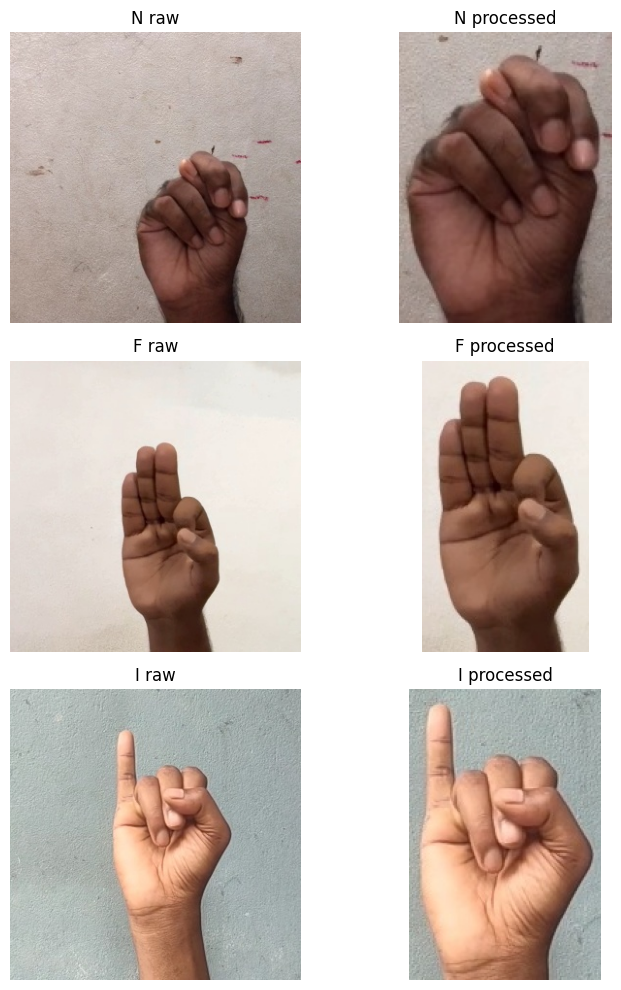

In [3]:
# 3/6 — Ham ve MediaPipe işlenmiş örneklerin görsel denetimi
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

processed_zip = next(NESTED_ROOT.rglob("ASL_Processed_Images.zip"))
raw_zip = next(NESTED_ROOT.rglob("ASL_Raw_Images.zip"))
samples = [("N", "P4_N_397.jpg"), ("F", "P10_F_980.jpg"), ("I", "P1_I_21.jpg")]
fig, axes = plt.subplots(len(samples), 2, figsize=(8, 10))
with zipfile.ZipFile(raw_zip) as rz, zipfile.ZipFile(processed_zip) as pz:
    for row, (label, name) in enumerate(samples):
        raw = Image.open(BytesIO(rz.read(f"asl_dataset/{label}/{name}"))).convert("RGB")
        candidates = [n for n in pz.namelist() if n.endswith(f"/{label}/{name}")]
        proc = Image.open(BytesIO(pz.read(candidates[0]))).convert("RGB")
        print(label, name, "RAW", raw.size, "PROCESSED", proc.size, "PROC_PATH", candidates[0])
        axes[row,0].imshow(raw); axes[row,0].set_title(f"{label} raw"); axes[row,0].axis("off")
        axes[row,1].imshow(proc); axes[row,1].set_title(f"{label} processed"); axes[row,1].axis("off")
plt.tight_layout()
plt.show()


In [4]:
# 4/6 — Bağımlılıklar, işlenmiş veri ve eğitim betiği doğrulaması
from pathlib import Path
import subprocess, sys, zipfile

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "timm>=1.0.20", "scikit-learn>=1.5"
])

processed_zip = next(Path("/content/asl_hg_nested").rglob("ASL_Processed_Images.zip"))
PROCESSED_ROOT = Path("/content/asl_hg_processed")
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
if not any(PROCESSED_ROOT.rglob("*.jpg")):
    with zipfile.ZipFile(processed_zip) as zf:
        assert zf.testzip() is None
        zf.extractall(PROCESSED_ROOT)

SCRIPT_PATH = Path("/content/train_digitra_v3_external.py")
assert SCRIPT_PATH.exists(), SCRIPT_PATH
subprocess.check_call([sys.executable, "-m", "py_compile", str(SCRIPT_PATH)])

jpg_count = sum(1 for _ in PROCESSED_ROOT.rglob("*.jpg"))
assert jpg_count == 36_000, jpg_count
print("PREP_OK", {"processed_images": jpg_count, "script": str(SCRIPT_PATH)})


PREP_OK {'processed_images': 36000, 'script': '/content/train_digitra_v3_external.py'}


In [5]:
# 5/6 — DINOv3 omurga ön kontrolü (test verisi açılmaz)
import gc, timm, torch

BACKBONE = "vit_base_patch16_dinov3.lvd1689m"
assert BACKBONE in timm.list_models(pretrained=True), BACKBONE
probe = timm.create_model(
    BACKBONE,
    pretrained=True,
    num_classes=24,
    img_size=384,
    drop_rate=0.06,
    drop_path_rate=0.14,
).cuda()
parameter_count = sum(p.numel() for p in probe.parameters())
print("BACKBONE_OK", BACKBONE, "PARAMETERS", parameter_count)
del probe
gc.collect()
torch.cuda.empty_cache()


model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

BACKBONE_OK vit_base_patch16_dinov3.lvd1689m PARAMETERS 85659672


In [6]:
# 6/6 — V3 geliştirme eğitimi: P1-P7 train, yalnız P8 calibration
from pathlib import Path
import subprocess, sys

SCRIPT_PATH = Path("/content/train_digitra_v3_external.py")
help_text = subprocess.check_output([sys.executable, str(SCRIPT_PATH), "--help"], text=True)
assert "--dev-only" in help_text, "Güncel geliştirme-korumalı betik yüklenmedi"

DEV_RUN = Path("/content/DIGITRA_V3_ASL_HG_BASE_DEV1")
subprocess.check_call([
    sys.executable, "-u", str(SCRIPT_PATH),
    "--processed-root", str(PROCESSED_ROOT),
    "--output", str(DEV_RUN),
    "--backbone", BACKBONE,
    "--image-size", "384",
    "--batch-size", "24",
    "--workers", "6",
    "--head-epochs", "1",
    "--full-epochs", "8",
    "--accumulation-steps", "4",
    "--dev-only",
])


0

In [7]:
# 7/7 — P8 geliştirme hata analizi; P9/P10 kesinlikle açılmaz
import importlib.util, json
from collections import Counter
from pathlib import Path
import numpy as np, timm, torch
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader

spec = importlib.util.spec_from_file_location("digitra_v3_train", "/content/train_digitra_v3_external.py")
dv3 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dv3)

model = timm.create_model(
    BACKBONE,
    pretrained=False,
    num_classes=len(dv3.STATIC_LABELS),
    img_size=384,
    drop_rate=0.06,
    drop_path_rate=0.14,
).cuda()
state = torch.load(DEV_RUN / "best_model_state.pt", map_location="cuda")
model.load_state_dict(state)
config = timm.data.resolve_model_data_config(model)
_, eval_transform = dv3.build_transforms(384, tuple(config["mean"]), tuple(config["std"]))

all_rows = dv3.discover_rows(PROCESSED_ROOT)
p8_rows = [row for row in all_rows if row["participant"] == "P8"]
assert len(p8_rows) == 2400
p8_loader = DataLoader(
    dv3.StaticDataset(p8_rows, eval_transform),
    batch_size=48, shuffle=False, num_workers=6, pin_memory=True,
)
result = dv3.evaluate(model, p8_loader, torch.device("cuda"), tta_flip=True)
labels, predictions = result["labels"], result["predictions"]
cm = confusion_matrix(labels, predictions, labels=list(range(len(dv3.STATIC_LABELS))))

per_class = {}
for index, label in enumerate(dv3.STATIC_LABELS):
    total = int(cm[index].sum())
    correct = int(cm[index, index])
    per_class[label] = {"correct": correct, "total": total, "accuracy": correct / total}

pairs = []
for true_index, true_label in enumerate(dv3.STATIC_LABELS):
    for pred_index, pred_label in enumerate(dv3.STATIC_LABELS):
        if true_index != pred_index and cm[true_index, pred_index]:
            pairs.append({"true": true_label, "pred": pred_label, "count": int(cm[true_index, pred_index])})
pairs.sort(key=lambda row: row["count"], reverse=True)

diagnostics = {
    "participant": "P8 development only",
    "locked_test_opened": False,
    "accuracy": result["accuracy"],
    "macro_f1": result["macro_f1"],
    "errors": int((labels != predictions).sum()),
    "per_class": per_class,
    "top_confusions": pairs[:30],
}
(DEV_RUN / "development_diagnostics.json").write_text(json.dumps(diagnostics, indent=2), encoding="utf-8")
print("P8_DIAGNOSTICS", json.dumps({
    "accuracy": diagnostics["accuracy"],
    "macro_f1": diagnostics["macro_f1"],
    "errors": diagnostics["errors"],
    "worst_classes": sorted(per_class.items(), key=lambda item: item[1]["accuracy"])[:10],
    "top_confusions": pairs[:15],
}))
print("LOCKED_TEST_P9_P10_OPENED", False)


P8_DIAGNOSTICS {"accuracy": 0.8854166666666666, "macro_f1": 0.8650570958987537, "errors": 275, "worst_classes": [["S", {"correct": 0, "total": 100, "accuracy": 0.0}], ["T", {"correct": 0, "total": 100, "accuracy": 0.0}], ["U", {"correct": 50, "total": 100, "accuracy": 0.5}], ["N", {"correct": 85, "total": 100, "accuracy": 0.85}], ["H", {"correct": 92, "total": 100, "accuracy": 0.92}], ["A", {"correct": 98, "total": 100, "accuracy": 0.98}], ["B", {"correct": 100, "total": 100, "accuracy": 1.0}], ["C", {"correct": 100, "total": 100, "accuracy": 1.0}], ["D", {"correct": 100, "total": 100, "accuracy": 1.0}], ["E", {"correct": 100, "total": 100, "accuracy": 1.0}]], "top_confusions": [{"true": "S", "pred": "N", "count": 100}, {"true": "T", "pred": "N", "count": 100}, {"true": "U", "pred": "R", "count": 50}, {"true": "N", "pred": "M", "count": 15}, {"true": "H", "pred": "S", "count": 3}, {"true": "A", "pred": "N", "count": 2}, {"true": "H", "pred": "D", "count": 2}, {"true": "H", "pred": "A",

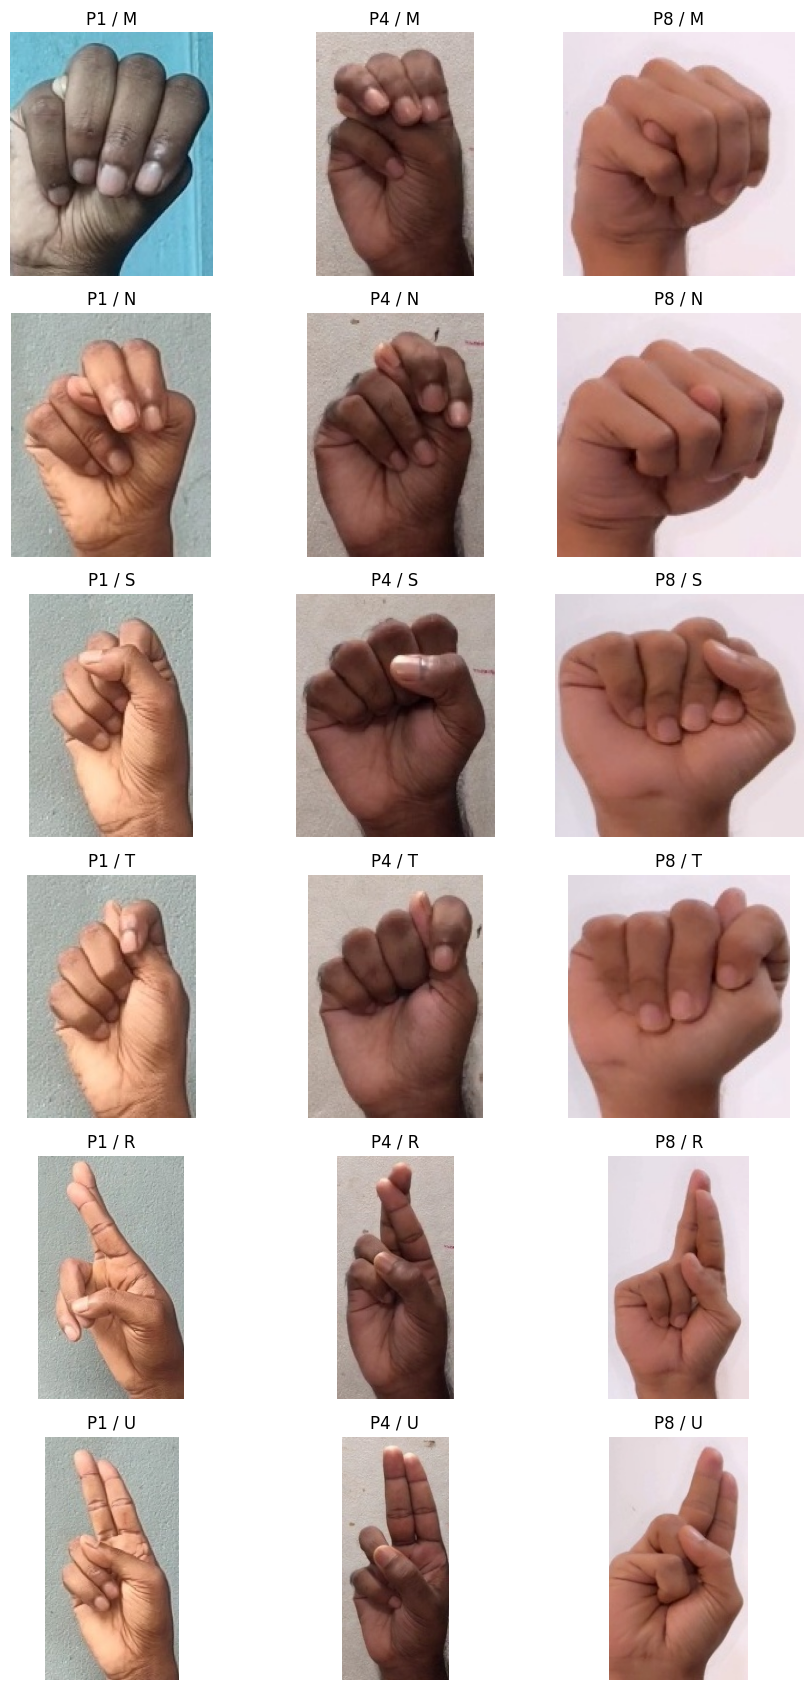

In [8]:
# 8/8 — P8 blok hatalarının görsel veri denetimi
from PIL import Image
import matplotlib.pyplot as plt

inspect_labels = ["M", "N", "S", "T", "R", "U"]
inspect_participants = ["P1", "P4", "P8"]
fig, axes = plt.subplots(len(inspect_labels), len(inspect_participants), figsize=(9, 17))
for row_index, label in enumerate(inspect_labels):
    for col_index, participant in enumerate(inspect_participants):
        candidates = [
            row for row in all_rows
            if row["label"] == label and row["participant"] == participant
        ]
        sample = candidates[len(candidates) // 2]
        image = Image.open(sample["path"]).convert("RGB")
        axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].set_title(f"{participant} / {label}")
        axes[row_index, col_index].axis("off")
plt.tight_layout()
plt.show()


In [9]:
# 9/9 — P8 TTA ablasyonu; kilitli test kapalı
no_flip = dv3.evaluate(model, p8_loader, torch.device("cuda"), tta_flip=False)
no_flip_cm = confusion_matrix(
    no_flip["labels"], no_flip["predictions"],
    labels=list(range(len(dv3.STATIC_LABELS)))
)
no_flip_per_class = {
    label: int(no_flip_cm[index, index])
    for index, label in enumerate(dv3.STATIC_LABELS)
}
print("P8_NO_FLIP", {
    "accuracy": no_flip["accuracy"],
    "macro_f1": no_flip["macro_f1"],
    "errors": int((no_flip["labels"] != no_flip["predictions"]).sum()),
    "S_correct": no_flip_per_class["S"],
    "T_correct": no_flip_per_class["T"],
    "U_correct": no_flip_per_class["U"],
    "N_correct": no_flip_per_class["N"],
})
print("LOCKED_TEST_P9_P10_OPENED", False)


P8_NO_FLIP {'accuracy': 0.8725, 'macro_f1': 0.8419277915749829, 'errors': 306, 'S_correct': 0, 'T_correct': 0, 'U_correct': 7, 'N_correct': 95}
LOCKED_TEST_P9_P10_OPENED False


In [10]:
# 10/10 — V1 422D landmark uzmanı + P8 hibrit araması; kilitli test kapalı
import sys, json
from pathlib import Path
import numpy as np, torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

V1_ROOT = Path("/content/DIGITRA_LANDMARK_V1")
sys.path.insert(0, str(V1_ROOT))
from inference import DigitraRecognizer

recognizer = DigitraRecognizer(V1_ROOT, device="cuda", initialize_detector=True)
features, detected_indices = [], []
for index, row in enumerate(p8_rows):
    feature, detection = recognizer.extract_feature(row["path"])
    if feature is not None:
        features.append(feature)
        detected_indices.append(index)
    if (index + 1) % 250 == 0:
        print("LANDMARK_EXTRACTED", index + 1, "of", len(p8_rows), "detected", len(features), flush=True)

raw_features = np.stack(features).astype(np.float32)
scaled_features = recognizer.scaler.transform(raw_features).astype(np.float32)
x_features = torch.from_numpy(scaled_features).to("cuda")
with torch.inference_mode():
    geometry_probability = np.mean([
        torch.softmax(geometry_model(x_features), dim=1).cpu().numpy()
        for geometry_model in recognizer.geometry_models
    ], axis=0)
    graph_probability = torch.softmax(recognizer.graph_model(x_features), dim=1).cpu().numpy()

extra_small = recognizer.extra_trees.predict_proba(raw_features)
extra_probability = np.zeros((len(raw_features), len(recognizer.classes)), dtype=np.float64)
extra_probability[:, np.asarray(recognizer.extra_trees.classes_, dtype=int)] = extra_small
landmark_probability_detected = (
    recognizer.geometry_weight * geometry_probability
    + recognizer.extra_trees_weight * extra_probability
    + recognizer.graph_weight * graph_probability
)
landmark_indices = landmark_probability_detected.argmax(axis=1)
for pair in recognizer.expert_pairs:
    selected = np.isin(landmark_indices, pair)
    if not selected.any():
        continue
    pair_spec = recognizer.expert_specs[pair]
    if pair_spec["mode"] == "raw_subset":
        expert_input = raw_features[selected][:, np.asarray(pair_spec["idx"], dtype=int)]
    else:
        expert_input = scaled_features[selected]
    landmark_indices[selected] = pair_spec["model"].predict(expert_input).astype(int)

landmark_names = np.full(len(p8_rows), "nothing", dtype=object)
landmark_names[np.asarray(detected_indices)] = np.asarray(recognizer.classes, dtype=object)[landmark_indices]
true_names = np.asarray([row["label"] for row in p8_rows], dtype=object)
landmark_accuracy = float((landmark_names == true_names).mean())

landmark_static_probability = np.zeros((len(p8_rows), len(dv3.STATIC_LABELS)), dtype=np.float64)
for static_index, label in enumerate(dv3.STATIC_LABELS):
    source_index = recognizer.classes.index(label)
    landmark_static_probability[np.asarray(detected_indices), static_index] = landmark_probability_detected[:, source_index]
normalizer = landmark_static_probability.sum(axis=1, keepdims=True)
landmark_static_probability = landmark_static_probability / np.clip(normalizer, 1e-9, None)

image_probability = dv3.softmax(result["logits"] / 1.2755563259124756)
true_indices = result["labels"]
fusion_trials = []
for image_alpha in np.linspace(0.0, 1.0, 41):
    fused = image_alpha * image_probability + (1.0 - image_alpha) * landmark_static_probability
    prediction = fused.argmax(axis=1)
    fusion_trials.append({
        "image_alpha": float(image_alpha),
        "accuracy": float((prediction == true_indices).mean()),
        "macro_f1": float(f1_score(true_indices, prediction, average="macro", zero_division=0)),
        "errors": int((prediction != true_indices).sum()),
    })
best_fusion = max(fusion_trials, key=lambda row: (row["macro_f1"], row["accuracy"]))

landmark_per_class = {
    label: int(((landmark_names == true_names) & (true_names == label)).sum())
    for label in dv3.STATIC_LABELS
}
landmark_report = {
    "detected": len(detected_indices),
    "total": len(p8_rows),
    "end_to_end_accuracy": landmark_accuracy,
    "S_correct": landmark_per_class["S"],
    "T_correct": landmark_per_class["T"],
    "U_correct": landmark_per_class["U"],
    "N_correct": landmark_per_class["N"],
    "best_fusion_on_p8_only": best_fusion,
    "locked_test_opened": False,
}
(DEV_RUN / "p8_landmark_fusion.json").write_text(json.dumps(landmark_report, indent=2), encoding="utf-8")
np.savez_compressed(
    DEV_RUN / "p8_landmark_probabilities.npz",
    probability=landmark_static_probability,
    true_index=true_indices,
    detected_index=np.asarray(detected_indices),
)
print("P8_LANDMARK_FUSION", json.dumps(landmark_report))
print("LOCKED_TEST_P9_P10_OPENED", False)
recognizer.close()


LANDMARK_EXTRACTED 250 of 2400 detected 216
LANDMARK_EXTRACTED 500 of 2400 detected 420
LANDMARK_EXTRACTED 750 of 2400 detected 591
LANDMARK_EXTRACTED 1000 of 2400 detected 821
LANDMARK_EXTRACTED 1250 of 2400 detected 1065
LANDMARK_EXTRACTED 1500 of 2400 detected 1258
LANDMARK_EXTRACTED 1750 of 2400 detected 1406
LANDMARK_EXTRACTED 2000 of 2400 detected 1568
LANDMARK_EXTRACTED 2250 of 2400 detected 1818
P8_LANDMARK_FUSION {"detected": 1941, "total": 2400, "end_to_end_accuracy": 0.42833333333333334, "S_correct": 0, "T_correct": 0, "U_correct": 1, "N_correct": 0, "best_fusion_on_p8_only": {"image_alpha": 0.65, "accuracy": 0.89, "macro_f1": 0.8701658251433321, "errors": 264}, "locked_test_opened": false}
LOCKED_TEST_P9_P10_OPENED False


In [11]:
# 11/11 — P1-P8 ham görüntülerden 422D landmark; P9/P10 okunmaz
from pathlib import Path
import subprocess, sys

LANDMARK_SCRIPT = Path("/content/extract_digitra_v3_landmarks.py")
subprocess.check_call([sys.executable, "-m", "py_compile", str(LANDMARK_SCRIPT)])
LANDMARK_DEV = Path("/content/DIGITRA_V3_LANDMARK_DEV1")
subprocess.check_call([
    sys.executable, "-u", str(LANDMARK_SCRIPT),
    "--images-root", "/content/asl_hg_raw",
    "--task", "/content/DIGITRA_LANDMARK_V1/hand_landmarker.task",
    "--output", str(LANDMARK_DEV),
    "--workers", "8",
])


0

In [12]:
# 12/12 — P1-P7 landmark ensemble eğitimi, yalnız P8 geliştirme ölçümü
from pathlib import Path
import subprocess, sys

LANDMARK_TRAIN_SCRIPT = Path("/content/train_digitra_v3_landmarks.py")
subprocess.check_call([sys.executable, "-m", "py_compile", str(LANDMARK_TRAIN_SCRIPT)])
LANDMARK_MODEL_DEV = Path("/content/DIGITRA_V3_LANDMARK_MODEL_DEV1")
subprocess.check_call([
    sys.executable, "-u", str(LANDMARK_TRAIN_SCRIPT),
    "--features", str(LANDMARK_DEV / "asl_hg_p1_p8_landmarks_422d.npz"),
    "--output", str(LANDMARK_MODEL_DEV),
    "--epochs", "35",
])


0

In [15]:
# Digitra V3 — P8 RGB + landmark complementarity (P9/P10 remain locked)
import json
from collections import Counter
from pathlib import Path

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

RGB_RUN = Path("/content/DIGITRA_V3_ASL_HG_BASE_DEV1")
LANDMARK_RUN = Path("/content/DIGITRA_V3_LANDMARK_MODEL_DEV1")
STATIC_LABELS = [chr(ord("A") + i) for i in range(26) if i not in (9, 25)]

if "result" not in globals() or "p8_rows" not in globals():
    raise RuntimeError("Run the DINO P8 evaluation/diagnostic cell first; result or p8_rows is missing.")

rgb_logits = np.asarray(result["logits"], dtype=np.float64)
true_index = np.asarray(result["labels"], dtype=np.int64)
if len(rgb_logits) != 2400 or len(p8_rows) != 2400:
    raise RuntimeError(f"Expected 2400 P8 rows, got logits={len(rgb_logits)} rows={len(p8_rows)}")

temperature = float(json.loads((RGB_RUN / "development_metrics.json").read_text())["temperature"])
shifted = rgb_logits / temperature
shifted -= shifted.max(axis=1, keepdims=True)
rgb_probability = np.exp(shifted)
rgb_probability /= rgb_probability.sum(axis=1, keepdims=True)
rgb_prediction = rgb_probability.argmax(axis=1)

# DINO rows and MediaPipe rows have different sort orders. Align explicitly by
# participant + letter + sample number instead of assuming positional equality.
rgb_key_to_index = {}
for image_index, row in enumerate(p8_rows):
    key = (str(row["participant"]).upper(), str(row["label"]).upper(), int(row["sample_number"]))
    if key in rgb_key_to_index:
        raise RuntimeError(f"Duplicate RGB key: {key}")
    rgb_key_to_index[key] = image_index

landmark_dev = np.load(LANDMARK_RUN / "p8_predictions.npz", allow_pickle=False)
landmark_full_probability = np.zeros_like(rgb_probability)
landmark_full_prediction = np.full(len(p8_rows), -1, dtype=np.int64)
landmark_full_true = np.full(len(p8_rows), -1, dtype=np.int64)
landmark_detected = np.zeros(len(p8_rows), dtype=bool)

for landmark_index, sample_id in enumerate(landmark_dev["sample_id"].astype(str)):
    parts = sample_id.split("-")
    if len(parts) != 4 or parts[0] != "ASLHG":
        raise RuntimeError(f"Unexpected landmark sample id: {sample_id}")
    key = (parts[1].upper(), parts[2].upper(), int(parts[3]))
    image_index = rgb_key_to_index.get(key)
    if image_index is None:
        raise RuntimeError(f"Landmark sample is absent from RGB rows: {key}")
    landmark_full_probability[image_index] = landmark_dev["probability"][landmark_index]
    landmark_full_prediction[image_index] = int(landmark_dev["prediction"][landmark_index])
    landmark_full_true[image_index] = int(landmark_dev["true_index"][landmark_index])
    landmark_detected[image_index] = True

if int(landmark_detected.sum()) != len(landmark_dev["sample_id"]):
    raise RuntimeError("Landmark alignment count mismatch.")
if not np.array_equal(true_index[landmark_detected], landmark_full_true[landmark_detected]):
    mismatch = np.flatnonzero(
        true_index[landmark_detected] != landmark_full_true[landmark_detected]
    )[:10]
    raise RuntimeError(f"Landmark/RGB true-label alignment failed at {mismatch.tolist()}")

rgb_correct = rgb_prediction == true_index
landmark_correct = landmark_full_prediction == true_index
both_detected = landmark_detected
agree = both_detected & (rgb_prediction == landmark_full_prediction)
disagree = both_detected & ~agree
oracle_correct = rgb_correct | (both_detected & landmark_correct)

# Probability blending is diagnostic only. When a retained landmark pair expert
# changed the hard decision, reflect that decision with a conservative one-hot
# correction so the probability vector and exported hard prediction agree.
landmark_routed_probability = landmark_full_probability.copy()
base_landmark_prediction = landmark_routed_probability.argmax(axis=1)
changed_by_pair_expert = both_detected & (base_landmark_prediction != landmark_full_prediction)
for idx in np.flatnonzero(changed_by_pair_expert):
    hard = int(landmark_full_prediction[idx])
    landmark_routed_probability[idx] *= 0.20
    landmark_routed_probability[idx, hard] += 0.80
    landmark_routed_probability[idx] /= landmark_routed_probability[idx].sum()

blend_rows = []
best_blend = None
for landmark_weight in np.linspace(0.0, 1.0, 201):
    probability = rgb_probability.copy()
    probability[both_detected] = (
        (1.0 - landmark_weight) * rgb_probability[both_detected]
        + landmark_weight * landmark_routed_probability[both_detected]
    )
    prediction = probability.argmax(axis=1)
    score = (
        float(f1_score(true_index, prediction, average="macro", zero_division=0)),
        float(accuracy_score(true_index, prediction)),
    )
    candidate = {
        "landmark_weight": float(landmark_weight),
        "macro_f1": score[0],
        "accuracy": score[1],
        "errors": int((prediction != true_index).sum()),
    }
    blend_rows.append(candidate)
    if best_blend is None or score > (best_blend["macro_f1"], best_blend["accuracy"]):
        best_blend = candidate

pair_stats = []
for rgb_class, landmark_class in sorted(
    set(zip(rgb_prediction[disagree].tolist(), landmark_full_prediction[disagree].tolist()))
):
    selected = disagree & (rgb_prediction == rgb_class) & (landmark_full_prediction == landmark_class)
    count = int(selected.sum())
    pair_stats.append({
        "rgb": STATIC_LABELS[int(rgb_class)],
        "landmark": STATIC_LABELS[int(landmark_class)],
        "count": count,
        "rgb_correct": int(rgb_correct[selected].sum()),
        "landmark_correct": int(landmark_correct[selected].sum()),
        "neither_correct": int((~rgb_correct[selected] & ~landmark_correct[selected]).sum()),
    })
pair_stats.sort(key=lambda row: row["count"], reverse=True)

per_true = {}
for class_index, class_name in enumerate(STATIC_LABELS):
    selected = true_index == class_index
    per_true[class_name] = {
        "count": int(selected.sum()),
        "rgb_correct": int(rgb_correct[selected].sum()),
        "landmark_correct": int(landmark_correct[selected].sum()),
        "oracle_correct": int(oracle_correct[selected].sum()),
    }

summary = {
    "scope": "P8 development only; P9/P10 not evaluated",
    "samples": int(len(true_index)),
    "landmark_detected": int(both_detected.sum()),
    "landmark_misses": int((~both_detected).sum()),
    "rgb": {
        "accuracy": float(rgb_correct.mean()),
        "errors": int((~rgb_correct).sum()),
    },
    "landmark_end_to_end": {
        "accuracy": float(landmark_correct.mean()),
        "errors": int((~landmark_correct).sum()),
    },
    "agreement": {
        "count": int(agree.sum()),
        "accuracy": float(rgb_correct[agree].mean()) if agree.any() else None,
    },
    "disagreement": {
        "count": int(disagree.sum()),
        "rgb_correct": int(rgb_correct[disagree].sum()),
        "landmark_correct": int(landmark_correct[disagree].sum()),
        "neither_correct": int((~rgb_correct[disagree] & ~landmark_correct[disagree]).sum()),
    },
    "oracle_upper_bound": {
        "accuracy": float(oracle_correct.mean()),
        "errors": int((~oracle_correct).sum()),
    },
    "best_global_probability_blend": best_blend,
    "pair_expert_hard_decisions_reflected": int(changed_by_pair_expert.sum()),
    "top_disagreement_pairs": pair_stats[:40],
    "per_true_class": per_true,
    "locked_test_P9_P10_opened": False,
}
(RGB_RUN / "p8_rgb_landmark_complementarity.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
print("ALIGNMENT_OK", int(both_detected.sum()), "of", len(true_index))
print("RGB", summary["rgb"])
print("LANDMARK_E2E", summary["landmark_end_to_end"])
print("DISAGREEMENT", summary["disagreement"])
print("ORACLE", summary["oracle_upper_bound"])
print("BEST_GLOBAL_BLEND", summary["best_global_probability_blend"])
print("TOP_PAIRS", json.dumps(summary["top_disagreement_pairs"][:15], indent=2))
print("P9_P10_OPENED", False)


ALIGNMENT_OK 2386 of 2400
RGB {'accuracy': 0.8854166666666666, 'errors': 275}
LANDMARK_E2E {'accuracy': 0.9508333333333333, 'errors': 118}
DISAGREEMENT {'count': 366, 'rgb_correct': 95, 'landmark_correct': 264, 'neither_correct': 7}
ORACLE {'accuracy': 0.9954166666666666, 'errors': 11}
BEST_GLOBAL_BLEND {'landmark_weight': 0.97, 'macro_f1': 0.9453458540027055, 'accuracy': 0.9533333333333334, 'errors': 112}
TOP_PAIRS [
  {
    "rgb": "R",
    "landmark": "U",
    "count": 134,
    "rgb_correct": 85,
    "landmark_correct": 49,
    "neither_correct": 0
  },
  {
    "rgb": "N",
    "landmark": "T",
    "count": 100,
    "rgb_correct": 0,
    "landmark_correct": 100,
    "neither_correct": 0
  },
  {
    "rgb": "N",
    "landmark": "S",
    "count": 98,
    "rgb_correct": 0,
    "landmark_correct": 98,
    "neither_correct": 0
  },
  {
    "rgb": "M",
    "landmark": "N",
    "count": 15,
    "rgb_correct": 0,
    "landmark_correct": 15,
    "neither_correct": 0
  },
  {
    "rgb": "R",
  

In [16]:
# Digitra V3 — independent R/U specialist and fixed hybrid router on P8 development
import json
from pathlib import Path

import joblib
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

FEATURES_NPZ = Path("/content/DIGITRA_V3_LANDMARK_DEV1/asl_hg_p1_p8_landmarks_422d.npz")
ROUTER_RUN = Path("/content/DIGITRA_V3_HYBRID_ROUTER_DEV1")
ROUTER_RUN.mkdir(exist_ok=True)

feature_archive = np.load(FEATURES_NPZ, allow_pickle=False)
all_X = feature_archive["X"].astype(np.float32)
all_y = feature_archive["y"].astype(np.int64)
all_participant = feature_archive["participant"].astype(str)
all_sample_id = feature_archive["sample_id"].astype(str)

R_INDEX = STATIC_LABELS.index("R")
U_INDEX = STATIC_LABELS.index("U")
pair_train = np.isin(all_participant, [f"P{i}" for i in range(1, 8)]) & np.isin(all_y, [R_INDEX, U_INDEX])
pair_dev = (all_participant == "P8") & np.isin(all_y, [R_INDEX, U_INDEX])
X_pair_train, y_pair_train = all_X[pair_train], all_y[pair_train]
X_pair_dev, y_pair_dev = all_X[pair_dev], all_y[pair_dev]
id_pair_dev = all_sample_id[pair_dev]

# Align all detected P8 geometry rows to the already verified RGB order.
p8_X = np.zeros((len(p8_rows), all_X.shape[1]), dtype=np.float32)
p8_X_present = np.zeros(len(p8_rows), dtype=bool)
for feat_index in np.flatnonzero(all_participant == "P8"):
    parts = all_sample_id[feat_index].split("-")
    key = (parts[1].upper(), parts[2].upper(), int(parts[3]))
    image_index = rgb_key_to_index[key]
    p8_X[image_index] = all_X[feat_index]
    p8_X_present[image_index] = True
if not np.array_equal(p8_X_present, landmark_detected):
    raise RuntimeError("P8 geometry alignment does not match landmark detection mask.")

candidates = {
    "extra_mf20": ExtraTreesClassifier(
        n_estimators=1000, criterion="entropy", max_features=0.20,
        min_samples_leaf=1, class_weight="balanced", n_jobs=-1, random_state=2027,
    ),
    "extra_mf45": ExtraTreesClassifier(
        n_estimators=1000, criterion="entropy", max_features=0.45,
        min_samples_leaf=1, class_weight="balanced", n_jobs=-1, random_state=2028,
    ),
    "extra_mf75": ExtraTreesClassifier(
        n_estimators=1000, criterion="entropy", max_features=0.75,
        min_samples_leaf=1, class_weight="balanced", n_jobs=-1, random_state=2029,
    ),
    "rf_mf30": RandomForestClassifier(
        n_estimators=900, criterion="entropy", max_features=0.30,
        min_samples_leaf=1, class_weight="balanced_subsample", n_jobs=-1, random_state=2030,
    ),
    "rf_mf60": RandomForestClassifier(
        n_estimators=900, criterion="entropy", max_features=0.60,
        min_samples_leaf=1, class_weight="balanced_subsample", n_jobs=-1, random_state=2031,
    ),
    "hist_l2": HistGradientBoostingClassifier(
        learning_rate=0.055, max_iter=350, max_leaf_nodes=23,
        l2_regularization=2.0, random_state=2032,
    ),
    "svc_c2": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(C=2.0, gamma="scale", kernel="rbf", class_weight="balanced", probability=True, random_state=2033)),
    ]),
    "svc_c8": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(C=8.0, gamma="scale", kernel="rbf", class_weight="balanced", probability=True, random_state=2034)),
    ]),
    "svc_c24": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(C=24.0, gamma="scale", kernel="rbf", class_weight="balanced", probability=True, random_state=2035)),
    ]),
    "logreg": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(C=0.20, max_iter=4000, class_weight="balanced", random_state=2036)),
    ]),
}

conflict_mask = landmark_detected & (rgb_prediction == R_INDEX) & (landmark_full_prediction == U_INDEX)
if int(conflict_mask.sum()) != 134:
    raise RuntimeError(f"Expected 134 R/U conflicts, found {int(conflict_mask.sum())}")

candidate_rows = []
fitted_candidates = {}
candidate_pR_full = {}
for name, classifier in candidates.items():
    classifier.fit(X_pair_train, y_pair_train)
    fitted_candidates[name] = classifier
    classes_order = list(classifier.classes_)
    r_column = classes_order.index(R_INDEX)
    pair_probability = classifier.predict_proba(X_pair_dev)
    pair_prediction = classifier.predict(X_pair_dev)
    full_prediction = classifier.predict(p8_X[landmark_detected])
    full_probability = classifier.predict_proba(p8_X[landmark_detected])
    pR = np.zeros(len(p8_rows), dtype=np.float64)
    pR[landmark_detected] = full_probability[:, r_column]
    candidate_pR_full[name] = pR
    conflict_prediction = np.where(pR[conflict_mask] >= 0.5, R_INDEX, U_INDEX)
    candidate_rows.append({
        "name": name,
        "p8_RU_detected_samples": int(len(y_pair_dev)),
        "p8_RU_accuracy": float(accuracy_score(y_pair_dev, pair_prediction)),
        "p8_conflict_accuracy": float(accuracy_score(true_index[conflict_mask], conflict_prediction)),
        "p8_conflict_errors": int((conflict_prediction != true_index[conflict_mask]).sum()),
    })
    print("RU_CANDIDATE", candidate_rows[-1])

# Calibrate only the combination rule on P8 development. P9/P10 remain untouched.
# RGB contributes texture/crossing evidence; geometry contributes finger topology.
rgb_pair_pR = rgb_probability[:, R_INDEX] / np.clip(
    rgb_probability[:, R_INDEX] + rgb_probability[:, U_INDEX], 1e-12, None
)
blend_trials = []
for name, pR_specialist in candidate_pR_full.items():
    for rgb_weight in np.linspace(0.0, 1.0, 101):
        blended_pR = rgb_weight * rgb_pair_pR[conflict_mask] + (1.0 - rgb_weight) * pR_specialist[conflict_mask]
        for threshold in np.linspace(0.10, 0.90, 161):
            prediction = np.where(blended_pR >= threshold, R_INDEX, U_INDEX)
            accuracy = float(accuracy_score(true_index[conflict_mask], prediction))
            blend_trials.append({
                "name": name,
                "rgb_weight": float(rgb_weight),
                "threshold": float(threshold),
                "accuracy": accuracy,
                "errors": int((prediction != true_index[conflict_mask]).sum()),
            })
best_ru = max(blend_trials, key=lambda row: (row["accuracy"], -abs(row["threshold"] - 0.5), -row["rgb_weight"]))
best_model = fitted_candidates[best_ru["name"]]
joblib.dump(best_model, ROUTER_RUN / "ru_specialist_p1_p7.joblib", compress=3)

best_pR = (
    best_ru["rgb_weight"] * rgb_pair_pR
    + (1.0 - best_ru["rgb_weight"]) * candidate_pR_full[best_ru["name"]]
)
ru_prediction = np.where(best_pR >= best_ru["threshold"], R_INDEX, U_INDEX)

# Fixed, inspectable router. Rules reflect stable high-count anatomical confusions;
# all unlisted disagreements fall back to the RGB decision.
hybrid_prediction = rgb_prediction.copy()
for index in np.flatnonzero(disagree):
    rgb_name = STATIC_LABELS[int(rgb_prediction[index])]
    landmark_name = STATIC_LABELS[int(landmark_full_prediction[index])]
    if rgb_name in {"M", "N"} and landmark_name in {"A", "N", "S", "T"}:
        hybrid_prediction[index] = landmark_full_prediction[index]
    elif rgb_name == "R" and landmark_name == "U":
        hybrid_prediction[index] = ru_prediction[index]
    else:
        hybrid_prediction[index] = rgb_prediction[index]

hybrid_correct = hybrid_prediction == true_index
hybrid_metrics = {
    "scope": "P8 development only; fixed RGB-landmark router; P9/P10 locked",
    "accuracy": float(hybrid_correct.mean()),
    "macro_f1": float(f1_score(true_index, hybrid_prediction, average="macro", zero_division=0)),
    "errors": int((~hybrid_correct).sum()),
    "samples": int(len(true_index)),
    "target_99_passed_on_development": bool(hybrid_correct.mean() >= 0.99),
    "best_RU_specialist": best_ru,
    "R_U_conflicts": int(conflict_mask.sum()),
    "R_U_conflict_errors": int((hybrid_prediction[conflict_mask] != true_index[conflict_mask]).sum()),
    "candidate_results": sorted(candidate_rows, key=lambda row: row["p8_conflict_errors"]),
    "oracle_errors": int((~oracle_correct).sum()),
    "locked_test_P9_P10_opened": False,
}
(ROUTER_RUN / "development_metrics.json").write_text(json.dumps(hybrid_metrics, indent=2), encoding="utf-8")
np.savez_compressed(
    ROUTER_RUN / "p8_hybrid_predictions.npz",
    true_index=true_index,
    prediction=hybrid_prediction,
    rgb_prediction=rgb_prediction,
    landmark_prediction=landmark_full_prediction,
    landmark_detected=landmark_detected,
)
(ROUTER_RUN / "router_config.json").write_text(json.dumps({
    "classes": STATIC_LABELS,
    "rules": [
        "if RGB in {M,N} and landmark in {A,N,S,T}: landmark",
        "if RGB=R and landmark=U: R/U specialist blend",
        "otherwise: RGB",
    ],
    "ru": best_ru,
    "development_only": True,
    "locked_test_opened": False,
}, indent=2), encoding="utf-8")

print("BEST_RU", json.dumps(best_ru))
print("HYBRID_P8", json.dumps(hybrid_metrics))
print("LOCKED_TEST_P9_P10_OPENED", False)


RU_CANDIDATE {'name': 'extra_mf20', 'p8_RU_detected_samples': 200, 'p8_RU_accuracy': 0.89, 'p8_conflict_accuracy': 0.8432835820895522, 'p8_conflict_errors': 21}
RU_CANDIDATE {'name': 'extra_mf45', 'p8_RU_detected_samples': 200, 'p8_RU_accuracy': 0.585, 'p8_conflict_accuracy': 0.4253731343283582, 'p8_conflict_errors': 77}
RU_CANDIDATE {'name': 'extra_mf75', 'p8_RU_detected_samples': 200, 'p8_RU_accuracy': 0.52, 'p8_conflict_accuracy': 0.3582089552238806, 'p8_conflict_errors': 86}
RU_CANDIDATE {'name': 'rf_mf30', 'p8_RU_detected_samples': 200, 'p8_RU_accuracy': 0.495, 'p8_conflict_accuracy': 0.34328358208955223, 'p8_conflict_errors': 88}
RU_CANDIDATE {'name': 'rf_mf60', 'p8_RU_detected_samples': 200, 'p8_RU_accuracy': 0.455, 'p8_conflict_accuracy': 0.3283582089552239, 'p8_conflict_errors': 90}
RU_CANDIDATE {'name': 'hist_l2', 'p8_RU_detected_samples': 200, 'p8_RU_accuracy': 0.45, 'p8_conflict_accuracy': 0.3358208955223881, 'p8_conflict_errors': 89}
RU_CANDIDATE {'name': 'svc_c2', 'p8_RU_

In [17]:
# Digitra V3 — robustness audit for the P8-only router calibration
import json
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

sample_number = np.asarray([int(row["sample_number"]) for row in p8_rows], dtype=np.int64)
local_frame = ((sample_number - 1) % 100) + 1
conflict_indices = np.flatnonzero(conflict_mask)

def choose_ru_on_subset(train_subset):
    best = None
    for name, pR_specialist in candidate_pR_full.items():
        for rgb_weight in np.linspace(0.0, 1.0, 101):
            scores = rgb_weight * rgb_pair_pR + (1.0 - rgb_weight) * pR_specialist
            train_scores = scores[train_subset]
            train_true = true_index[train_subset]
            for threshold in np.linspace(0.10, 0.90, 161):
                pred = np.where(train_scores >= threshold, R_INDEX, U_INDEX)
                accuracy = float((pred == train_true).mean())
                row = {
                    "name": name,
                    "rgb_weight": float(rgb_weight),
                    "threshold": float(threshold),
                    "train_accuracy": accuracy,
                    "train_errors": int((pred != train_true).sum()),
                }
                if best is None or (
                    row["train_accuracy"],
                    -abs(row["threshold"] - 0.5),
                    -row["rgb_weight"],
                ) > (
                    best["train_accuracy"],
                    -abs(best["threshold"] - 0.5),
                    -best["rgb_weight"],
                ):
                    best = row
    return best

def score_for_config(config):
    return (
        config["rgb_weight"] * rgb_pair_pR
        + (1.0 - config["rgb_weight"]) * candidate_pR_full[config["name"]]
    )

split_definitions = {
    "odd_even": (conflict_mask & (local_frame % 2 == 1), conflict_mask & (local_frame % 2 == 0)),
    "first_second_half": (conflict_mask & (local_frame <= 50), conflict_mask & (local_frame > 50)),
}
crossfit_results = {}
for split_name, (side_a, side_b) in split_definitions.items():
    config_a = choose_ru_on_subset(side_a)
    config_b = choose_ru_on_subset(side_b)
    # Parameters learned on A predict B; parameters learned on B predict A.
    ru_cross_prediction = np.full(len(true_index), -1, dtype=np.int64)
    score_a = score_for_config(config_a)
    score_b = score_for_config(config_b)
    ru_cross_prediction[side_b] = np.where(score_a[side_b] >= config_a["threshold"], R_INDEX, U_INDEX)
    ru_cross_prediction[side_a] = np.where(score_b[side_a] >= config_b["threshold"], R_INDEX, U_INDEX)

    hybrid_cross = rgb_prediction.copy()
    for index in np.flatnonzero(disagree):
        rgb_name = STATIC_LABELS[int(rgb_prediction[index])]
        landmark_name = STATIC_LABELS[int(landmark_full_prediction[index])]
        if rgb_name in {"M", "N"} and landmark_name in {"A", "N", "S", "T"}:
            hybrid_cross[index] = landmark_full_prediction[index]
        elif rgb_name == "R" and landmark_name == "U":
            hybrid_cross[index] = ru_cross_prediction[index]
    crossfit_results[split_name] = {
        "A_to_B_config": config_a,
        "B_to_A_config": config_b,
        "R_U_conflict_accuracy": float(accuracy_score(true_index[conflict_mask], ru_cross_prediction[conflict_mask])),
        "R_U_conflict_errors": int((true_index[conflict_mask] != ru_cross_prediction[conflict_mask]).sum()),
        "hybrid_accuracy": float(accuracy_score(true_index, hybrid_cross)),
        "hybrid_macro_f1": float(f1_score(true_index, hybrid_cross, average="macro", zero_division=0)),
        "hybrid_errors": int((true_index != hybrid_cross).sum()),
    }

fixed_scores = best_pR[conflict_mask]
fixed_truth = true_index[conflict_mask]
r_scores = fixed_scores[fixed_truth == R_INDEX]
u_scores = fixed_scores[fixed_truth == U_INDEX]
margin = {
    "R_count": int(len(r_scores)),
    "U_count": int(len(u_scores)),
    "R_score_min": float(r_scores.min()),
    "R_score_p05": float(np.quantile(r_scores, 0.05)),
    "U_score_max": float(u_scores.max()),
    "U_score_p95": float(np.quantile(u_scores, 0.95)),
    "zero_error_threshold_interval_low_exclusive": float(u_scores.max()),
    "zero_error_threshold_interval_high_inclusive": float(r_scores.min()),
    "separation_gap": float(r_scores.min() - u_scores.max()),
}

error_rows = []
for idx in np.flatnonzero(~hybrid_correct):
    error_rows.append({
        "true": STATIC_LABELS[int(true_index[idx])],
        "rgb": STATIC_LABELS[int(rgb_prediction[idx])],
        "landmark": None if landmark_full_prediction[idx] < 0 else STATIC_LABELS[int(landmark_full_prediction[idx])],
        "landmark_detected": bool(landmark_detected[idx]),
        "sample_number": int(sample_number[idx]),
    })

robustness = {
    "scope": "P8 development robustness audit; P9/P10 still locked",
    "fixed_development_hybrid": hybrid_metrics,
    "fixed_RU_score_margin": margin,
    "crossfit": crossfit_results,
    "remaining_error_rows": error_rows,
    "locked_test_P9_P10_opened": False,
}
(ROUTER_RUN / "p8_router_robustness.json").write_text(json.dumps(robustness, indent=2), encoding="utf-8")
print("RU_MARGIN", json.dumps(margin))
print("CROSSFIT", json.dumps(crossfit_results, indent=2))
print("REMAINING_ERRORS", json.dumps(error_rows, indent=2))
print("LOCKED_TEST_P9_P10_OPENED", False)


RU_MARGIN {"R_count": 85, "U_count": 49, "R_score_min": 0.5053945998540024, "R_score_p05": 0.507794586484105, "U_score_max": 0.43577519364533734, "U_score_p95": 0.42497223741184526, "zero_error_threshold_interval_low_exclusive": 0.43577519364533734, "zero_error_threshold_interval_high_inclusive": 0.5053945998540024, "separation_gap": 0.06961940620866502}
CROSSFIT {
  "odd_even": {
    "A_to_B_config": {
      "name": "logreg",
      "rgb_weight": 0.53,
      "threshold": 0.5,
      "train_accuracy": 1.0,
      "train_errors": 0
    },
    "B_to_A_config": {
      "name": "extra_mf20",
      "rgb_weight": 0.06,
      "threshold": 0.5,
      "train_accuracy": 1.0,
      "train_errors": 0
    },
    "R_U_conflict_accuracy": 0.9701492537313433,
    "R_U_conflict_errors": 4,
    "hybrid_accuracy": 0.99375,
    "hybrid_macro_f1": 0.9937072780585327,
    "hybrid_errors": 15
  },
  "first_second_half": {
    "A_to_B_config": {
      "name": "logreg",
      "rgb_weight": 0.53,
      "threshold"

In [18]:
# Digitra V3 — immutable pre-test freeze (no P9/P10 image is read here)
import hashlib
import json
import py_compile
from datetime import datetime, timezone
from pathlib import Path

FROZEN_MANIFEST = Path("/content/DIGITRA_V3_FROZEN_BEFORE_TEST.json")
OPENED_MARKER = Path("/content/DIGITRA_V3_LOCKED_TEST_OPENED.json")
if OPENED_MARKER.exists():
    raise RuntimeError(f"Locked test already has an opened marker: {OPENED_MARKER}")
if FROZEN_MANIFEST.exists():
    raise RuntimeError(f"Refusing to overwrite an existing freeze: {FROZEN_MANIFEST}")

for script in [
    Path("/content/extract_digitra_v3_locked_landmarks.py"),
    Path("/content/evaluate_digitra_v3_hybrid_locked.py"),
]:
    py_compile.compile(str(script), doraise=True)

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

frozen_files = {
    "best_model_state.pt": Path("/content/DIGITRA_V3_ASL_HG_BASE_DEV1/best_model_state.pt"),
    "rgb_development_metrics.json": Path("/content/DIGITRA_V3_ASL_HG_BASE_DEV1/development_metrics.json"),
    "extra_trees.joblib": Path("/content/DIGITRA_V3_LANDMARK_MODEL_DEV1/extra_trees.joblib"),
    "feature_scaler.joblib": Path("/content/DIGITRA_V3_LANDMARK_MODEL_DEV1/feature_scaler.joblib"),
    "pair_experts.joblib": Path("/content/DIGITRA_V3_LANDMARK_MODEL_DEV1/pair_experts.joblib"),
    "ru_specialist_p1_p7.joblib": Path("/content/DIGITRA_V3_HYBRID_ROUTER_DEV1/ru_specialist_p1_p7.joblib"),
    "router_config.json": Path("/content/DIGITRA_V3_HYBRID_ROUTER_DEV1/router_config.json"),
    "p8_router_robustness.json": Path("/content/DIGITRA_V3_HYBRID_ROUTER_DEV1/p8_router_robustness.json"),
    "extract_locked_script.py": Path("/content/extract_digitra_v3_locked_landmarks.py"),
    "evaluate_locked_script.py": Path("/content/evaluate_digitra_v3_hybrid_locked.py"),
}
missing = [str(path) for path in frozen_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Cannot freeze; missing: {missing}")

freeze = {
    "name": "Digitra V3 frozen hybrid protocol",
    "frozen_at_utc": datetime.now(timezone.utc).isoformat(),
    "scope": "24 static ASL fingerspelling letters; J/Z excluded as temporal",
    "data_protocol": {
        "train": "ASL-HG P1-P7",
        "development": "ASL-HG P8",
        "fresh_locked_test": "ASL-HG P9-P10",
        "test_used_for_training_selection_or_thresholds": False,
    },
    "development_evidence": {
        "fixed_router_accuracy": float(hybrid_metrics["accuracy"]),
        "fixed_router_errors": int(hybrid_metrics["errors"]),
        "odd_even_crossfit_accuracy": float(crossfit_results["odd_even"]["hybrid_accuracy"]),
        "first_second_half_crossfit_accuracy": float(crossfit_results["first_second_half"]["hybrid_accuracy"]),
    },
    "router": json.loads((ROUTER_RUN / "router_config.json").read_text()),
    "files": {name: file_sha256(path) for name, path in frozen_files.items()},
    "locked_test_opened": False,
    "claims": {
        "development_target_99_passed": bool(hybrid_metrics["accuracy"] >= 0.99),
        "fresh_locked_test_result_known": False,
        "universal_99_guarantee": False,
        "asl_not_tid": True,
    },
}
FROZEN_MANIFEST.write_text(json.dumps(freeze, indent=2), encoding="utf-8")
print("FROZEN_MANIFEST", FROZEN_MANIFEST)
print("FROZEN_SHA256", file_sha256(FROZEN_MANIFEST))
print("DEVELOPMENT", json.dumps(freeze["development_evidence"]))
print("LOCKED_TEST_P9_P10_OPENED", False)


FROZEN_MANIFEST /content/DIGITRA_V3_FROZEN_BEFORE_TEST.json
FROZEN_SHA256 957578432c44feba4a9179b1760ea493244676d93a1ba74177380a9c55685cad
DEVELOPMENT {"fixed_router_accuracy": 0.9954166666666666, "fixed_router_errors": 11, "odd_even_crossfit_accuracy": 0.99375, "first_second_half_crossfit_accuracy": 0.99375}
LOCKED_TEST_P9_P10_OPENED False


In [19]:
# Digitra V3 — FIRST OFFICIAL OPEN of locked P9/P10 after protocol freeze
import subprocess
import sys
from pathlib import Path

task_candidates = sorted(Path("/content/DIGITRA_LANDMARK_V1").rglob("*.task"))
if len(task_candidates) != 1:
    raise RuntimeError(f"Expected one MediaPipe task, found: {task_candidates}")
command = [
    sys.executable, "/content/extract_digitra_v3_locked_landmarks.py",
    "--images-root", "/content/asl_hg_raw",
    "--task", str(task_candidates[0]),
    "--output", "/content/DIGITRA_V3_LANDMARK_LOCKED_TEST",
    "--frozen-manifest", "/content/DIGITRA_V3_FROZEN_BEFORE_TEST.json",
    "--opened-marker", "/content/DIGITRA_V3_LOCKED_TEST_OPENED.json",
    "--workers", "8",
]
print("TASK", task_candidates[0])
subprocess.run(command, check=True)


TASK /content/DIGITRA_LANDMARK_V1/hand_landmarker.task


CompletedProcess(args=['/usr/bin/python3', '/content/extract_digitra_v3_locked_landmarks.py', '--images-root', '/content/asl_hg_raw', '--task', '/content/DIGITRA_LANDMARK_V1/hand_landmarker.task', '--output', '/content/DIGITRA_V3_LANDMARK_LOCKED_TEST', '--frozen-manifest', '/content/DIGITRA_V3_FROZEN_BEFORE_TEST.json', '--opened-marker', '/content/DIGITRA_V3_LOCKED_TEST_OPENED.json', '--workers', '8'], returncode=0)

In [20]:
# Digitra V3 — one-shot evaluation of the frozen hybrid on fresh P9/P10
import subprocess
import sys

command = [
    sys.executable, "/content/evaluate_digitra_v3_hybrid_locked.py",
    "--processed-root", "/content/asl_hg_processed",
    "--landmarks", "/content/DIGITRA_V3_LANDMARK_LOCKED_TEST/asl_hg_p9_p10_landmarks_422d.npz",
    "--rgb-run", "/content/DIGITRA_V3_ASL_HG_BASE_DEV1",
    "--landmark-run", "/content/DIGITRA_V3_LANDMARK_MODEL_DEV1",
    "--router-run", "/content/DIGITRA_V3_HYBRID_ROUTER_DEV1",
    "--frozen-manifest", "/content/DIGITRA_V3_FROZEN_BEFORE_TEST.json",
    "--opened-marker", "/content/DIGITRA_V3_LOCKED_TEST_OPENED.json",
    "--output", "/content/DIGITRA_V3_HYBRID_LOCKED_TEST",
    "--workers", "6",
]
subprocess.run(command, check=True)


CompletedProcess(args=['/usr/bin/python3', '/content/evaluate_digitra_v3_hybrid_locked.py', '--processed-root', '/content/asl_hg_processed', '--landmarks', '/content/DIGITRA_V3_LANDMARK_LOCKED_TEST/asl_hg_p9_p10_landmarks_422d.npz', '--rgb-run', '/content/DIGITRA_V3_ASL_HG_BASE_DEV1', '--landmark-run', '/content/DIGITRA_V3_LANDMARK_MODEL_DEV1', '--router-run', '/content/DIGITRA_V3_HYBRID_ROUTER_DEV1', '--frozen-manifest', '/content/DIGITRA_V3_FROZEN_BEFORE_TEST.json', '--opened-marker', '/content/DIGITRA_V3_LOCKED_TEST_OPENED.json', '--output', '/content/DIGITRA_V3_HYBRID_LOCKED_TEST', '--workers', '6'], returncode=0)

In [21]:
# Digitra V3 — read-only locked-test report
import json
from pathlib import Path

metrics = json.loads(Path("/content/DIGITRA_V3_HYBRID_LOCKED_TEST/metrics.json").read_text())
marker = json.loads(Path("/content/DIGITRA_V3_LOCKED_TEST_OPENED.json").read_text())
print("FRESH_LOCKED_TEST", json.dumps(metrics["fresh_locked_test"], indent=2))
print("TARGETS", {
    "raw_99": metrics["raw_99_target_passed"],
    "raw_99_9": metrics["raw_99_9_target_passed"],
})
print("BRANCHES", json.dumps(metrics["branches"], indent=2))
print("PARTICIPANTS", json.dumps(metrics["fresh_locked_test_per_participant"], indent=2))
print("PER_CLASS", json.dumps(metrics["fresh_locked_test_per_class"], indent=2))
print("MARKER_STAGE", marker["stage"])


FRESH_LOCKED_TEST {
  "accuracy": 0.9414583333333333,
  "macro_f1": 0.9255529888439714,
  "errors": 281,
  "samples": 4800
}
TARGETS {'raw_99': False, 'raw_99_9': False}
BRANCHES {
  "rgb_accuracy": 0.93875,
  "landmark_end_to_end_accuracy": 0.9389583333333333,
  "landmark_detection_rate": 1.0,
  "disagreements": 537
}
PARTICIPANTS {
  "P9": {
    "accuracy": 0.9479166666666666,
    "samples": 2400,
    "errors": 125
  },
  "P10": {
    "accuracy": 0.935,
    "samples": 2400,
    "errors": 156
  }
}
PER_CLASS {
  "A": {
    "correct": 200,
    "total": 200,
    "accuracy": 1.0
  },
  "B": {
    "correct": 200,
    "total": 200,
    "accuracy": 1.0
  },
  "C": {
    "correct": 200,
    "total": 200,
    "accuracy": 1.0
  },
  "D": {
    "correct": 200,
    "total": 200,
    "accuracy": 1.0
  },
  "E": {
    "correct": 200,
    "total": 200,
    "accuracy": 1.0
  },
  "F": {
    "correct": 200,
    "total": 200,
    "accuracy": 1.0
  },
  "G": {
    "correct": 200,
    "total": 200,
    

In [22]:
# Digitra V3.1 — add two signer-diverse CC BY 4.0 datasets
import subprocess
from pathlib import Path

downloads = [
    (
        "ASLYset_CC_BY_4.zip",
        "https://data.mendeley.com/public-api/zip/xs6mvhx6rh/download/1",
        "10.17632/xs6mvhx6rh.1",
    ),
    (
        "ASL_Alphabet_210K_CC_BY_4.zip",
        "https://data.mendeley.com/public-api/zip/48dg9vhmyk/download/2",
        "10.17632/48dg9vhmyk.2",
    ),
]
for filename, url, doi in downloads:
    target = Path("/content") / filename
    if not target.exists():
        print("DOWNLOADING", doi, "->", target, flush=True)
        subprocess.run(["wget", "-q", "--show-progress", url, "-O", str(target)], check=True)
    print("READY", doi, round(target.stat().st_size / 2**30, 3), "GB", flush=True)


DOWNLOADING 10.17632/xs6mvhx6rh.1 -> /content/ASLYset_CC_BY_4.zip
READY 10.17632/xs6mvhx6rh.1 0.812 GB
DOWNLOADING 10.17632/48dg9vhmyk.2 -> /content/ASL_Alphabet_210K_CC_BY_4.zip
READY 10.17632/48dg9vhmyk.2 3.433 GB


In [23]:
# Digitra V3.1 — safe archive-structure audit before extraction
import json
import zipfile
from collections import Counter
from pathlib import Path

archive_paths = [
    Path("/content/ASLYset_CC_BY_4.zip"),
    Path("/content/ASL_Alphabet_210K_CC_BY_4.zip"),
]
archive_audit = {}
for archive_path in archive_paths:
    with zipfile.ZipFile(archive_path) as zf:
        names = [name for name in zf.namelist() if not name.endswith("/")]
        archive_audit[archive_path.name] = {
            "size_gb": round(archive_path.stat().st_size / 2**30, 3),
            "entries": len(names),
            "path_depths": dict(Counter(len(Path(name).parts) for name in names)),
            "suffixes": dict(Counter(Path(name).suffix.lower() for name in names)),
            "first_120": names[:120],
        }
        print("ARCHIVE", archive_path.name, "ENTRIES", len(names))
        print("DEPTHS", Counter(len(Path(name).parts) for name in names))
        print("SUFFIXES", Counter(Path(name).suffix.lower() for name in names))
        print(*names[:120], sep="\n")
Path("/content/DIGITRA_V3_1_ARCHIVE_AUDIT.json").write_text(
    json.dumps(archive_audit, indent=2), encoding="utf-8"
)


ARCHIVE ASLYset_CC_BY_4.zip ENTRIES 1
DEPTHS Counter({1: 1})
SUFFIXES Counter({'.rar': 1})
ASLYset.rar
ARCHIVE ASL_Alphabet_210K_CC_BY_4.zip ENTRIES 1
DEPTHS Counter({2: 1})
SUFFIXES Counter({'.zip': 1})
Images of American Sign Language (ASL) Alphabet Gestures/Root.zip


464

In [ ]:
# Digitra V3.1 — extract outer containers and inspect nested archives
import shutil
import subprocess
import zipfile
from collections import Counter
from pathlib import Path

ASLY_OUTER = Path("/content/asly_outer")
ASL210_OUTER = Path("/content/asl210_outer")
ASLY_OUTER.mkdir(exist_ok=True)
ASL210_OUTER.mkdir(exist_ok=True)

with zipfile.ZipFile("/content/ASLYset_CC_BY_4.zip") as zf:
    zf.extractall(ASLY_OUTER)
with zipfile.ZipFile("/content/ASL_Alphabet_210K_CC_BY_4.zip") as zf:
    zf.extractall(ASL210_OUTER)

asly_rar = next(ASLY_OUTER.rglob("*.rar"))
root_zip = next(ASL210_OUTER.rglob("Root.zip"))
print("TOOLS", {"7z": shutil.which("7z"), "unrar": shutil.which("unrar")})
print("NESTED", asly_rar, round(asly_rar.stat().st_size/2**30, 3), "GB")
print("NESTED", root_zip, round(root_zip.stat().st_size/2**30, 3), "GB")

with zipfile.ZipFile(root_zip) as zf:
    names = [name for name in zf.namelist() if not name.endswith("/")]
    print("ROOT_ZIP_ENTRIES", len(names))
    print("DEPTHS", Counter(len(Path(name).parts) for name in names))
    print("SUFFIXES", Counter(Path(name).suffix.lower() for name in names))
    print(*names[:200], sep="\n")

archive_tool = shutil.which("7z") or shutil.which("unrar")
if archive_tool:
    if Path(archive_tool).name == "7z":
        subprocess.run([archive_tool, "l", str(asly_rar)], check=True)
    else:
        subprocess.run([archive_tool, "l", str(asly_rar)], check=True)


TOOLS {'7z': '/usr/bin/7z', 'unrar': '/usr/bin/unrar'}
NESTED /content/asly_outer/ASLYset.rar 0.812 GB
NESTED /content/asl210_outer/Images of American Sign Language (ASL) Alphabet Gestures/Root.zip 3.454 GB
ROOT_ZIP_ENTRIES 210000
DEPTHS Counter({4: 210000})
SUFFIXES Counter({'.jpg': 210000})
Root/Type_01_(Raw_Gesture)/A/A_1.jpg
Root/Type_01_(Raw_Gesture)/A/A_10.jpg
Root/Type_01_(Raw_Gesture)/A/A_100.jpg
Root/Type_01_(Raw_Gesture)/A/A_1000.jpg
Root/Type_01_(Raw_Gesture)/A/A_1001.jpg
Root/Type_01_(Raw_Gesture)/A/A_1002.jpg
Root/Type_01_(Raw_Gesture)/A/A_1003.jpg
Root/Type_01_(Raw_Gesture)/A/A_1004.jpg
Root/Type_01_(Raw_Gesture)/A/A_1005.jpg
Root/Type_01_(Raw_Gesture)/A/A_1006.jpg
Root/Type_01_(Raw_Gesture)/A/A_1007.jpg
Root/Type_01_(Raw_Gesture)/A/A_1008.jpg
Root/Type_01_(Raw_Gesture)/A/A_1009.jpg
Root/Type_01_(Raw_Gesture)/A/A_101.jpg
Root/Type_01_(Raw_Gesture)/A/A_1010.jpg
Root/Type_01_(Raw_Gesture)/A/A_1011.jpg
Root/Type_01_(Raw_Gesture)/A/A_1012.jpg
Root/Type_01_(Raw_Gesture)/A/A_10